# 트리 알고리즘
---

## 05-1 결정 트리

알코올 도수, 당도, pH 값을 기반으로 레드 와인과 화이트 와인을 구분하는 것이 가능할까?

---

### 로지스틱 회귀로 와인 분류하기

In [2]:
import pandas as pd

wine = pd.read_csv("./data/wine_csv_data.csv")

wine.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


네 번째 열(`class`)를 보면 타깃값으로
  - 0이면 레드 와인
  - 1이면 화이트 와인으로 구분된다.

정리하면 이번 문제는 레드 와인과 화이트 와인을 구분하는 이진 분류 문제로,\
화이트 와인이 양성 클래스이다.

<br>

pandas에는 다음과 같은 유용한 메서드가 존재한다 :
  - `info()` : 해당 메서드를 통해서 각 열의 데이터 타입과 누락된 데이터가 존재하는지 확인 가능하다.
  - `describe()` : 해당 메서드는 열에 대한 간략한 통계를 출력한다.

In [4]:
wine.info()

wine.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


이를 기반으로 다음과 같은 해석이 가능할 것 같다 :
    - 데이터 값의 최소와 최대를 보면 범위를 알 수 있는데 `sugar`의 범위가 압도적으로 크다.
    - 표준편차도 비교를 해보면, 이 또한 `sugar`가 훨씬 크다.
    - `sugar`의 중간값은 3인데 최대값이 65인 것을 통해 극단적인 값(outlier)가 존재하는 걸 알 수 있다.

&rArr; 즉, 정리하면 스케일링 하지 않으면 실제 중요도와는 관계없이 `sugar`가 지배할 위험이 존재한다.

---

#### 데이터 스케일링은 어떨 때 진행해야 하지?

1) 거리 기반 모델인 경우 ( KNN, K-menas, SVM, PCA ...)

        - 거리 계산이 핵심이기 대문에 하나라도 범위 차이가 큰 경우에는 진행해줘야 한다.

2) 경사하강법 기반 모델인 경우 (Logistic Regression, Linear Regression, Neural Network ...)

        - `feature` 범위에 차이가 있거나, 학습이 느리거나 불안정하다면 진행해줘야 한다.

3) 값 범위 차이가 크거나, 단위가 다른 경우

        - 이건 모델 상관없이 중요하다

IF. 트리 기반(Decision Tree, Random Forest ...)의 경우에는 "분할 기준"만을 보기 때문에 하지 않아도 된다.\
또는 이미 동일 스케일인 경우에도 하지 않아도 된다.

##### 그럼 어떤 스케일러를 써야해?

- `StandardScaler` : 그냥 기본형. 대부분의 상황에 가능하다.
- `MinMaxScaler` : 값 범위가 중요한 경우(0~1 필요). 이미지, 신경망 입력 등의 경우. (outlier 있는 경우 쓰면 큰일 난다...)
- `RubustScaler` : outlier가 많은 경우
- `log scaling` : 분포가 한쪽으로 치우진 경우. 값이 0보다 큰 경우.

---

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression

data = wine[["alcohol", "sugar", "pH"]]
target = wine["class"]

# test_size 매개변수를 통해 20%를 테스트 세트로 나눴다. (기본값 25%)
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42
)

print(train_input.shape, test_input.shape)

ss = StandardScaler()
ss.fit(train_input)

train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

# # 다항 feature 추가
# poly = PolynomialFeatures(degree=2, include_bias=False)
# train_poly = poly.fit_transform(train_scaled)
# test_poly = poly.transform(test_scaled)

lr = LogisticRegression()

# C 규제 추가
for c in [0.01, 0.1, 1, 10, 100]:
    lr = LogisticRegression(C=c, max_iter=1000)
    lr.fit(train_poly,train_target)
    print(c, lr.score(train_poly, train_target)) # 100 0.833365403117183
    print(c, lr.score(test_poly, test_target)) # 100 0.8284615384615385
    
# lr.fit(train_scaled, train_target)
# lr.fit(train_poly, train_target)

# print(lr.score(train_scaled, train_target)) # 0.7808350971714451
# print(lr.score(test_scaled, test_target)) # 0.7776923076923077
# print(lr.score(train_poly, train_target)) # 0.8285549355397345
# print(lr.score(test_poly, test_target)) # 0.8261538461538461

print(lr.coef_, lr.intercept_)

(5197, 3) (1300, 3)
0.01 0.787569751779873
0.01 0.786923076923077
0.1 0.813931114104291
0.1 0.8138461538461539
1 0.8285549355397345
1 0.8261538461538461
10 0.833365403117183
10 0.8284615384615385
100 0.833365403117183
100 0.8284615384615385
[[ 0.49198454  3.46327093 -0.8039617  -0.00839677 -0.35824654 -0.25038387
   3.57187191 -0.00765107  0.15346284]] [1.0894674]


기존의 점수가 너무 낮아서 이걸로는 화이트 와인을 골라내는 것이 어렵다고 보인다.\
그에 따라 이전의 여러 시도를 적용해 보았다 :
- `PolynomialFeature` 변환기 클래스를 사용해서 "다항 feature"를 추가해서 모델 복잡하게 만들기
- C(규제 파라미터)를 통해서 모델의 자유도를 조절하기

&rArr; 그럼에도 불구하고 여전히 만족스러운 점수를 얻지 못할뿐더러,\
    각 계수와 절편을 살펴보아도 해당 모델에 대해 충분히 잘 설명할 수 있을지 자신이 없다..

---

### 결정 트리

**결정 트리(Decision Tree)** 는 마치 스무고개와 같다.\
데이터를 잘 나눌 수 있는 질문을 찾는다면, 계속 질문을 추가해서 분류 정확도를 높일 수 있는 것이다.

In [22]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

0.996921300750433
0.8592307692307692


훈련 점수가 굉장히 잘 나온 것을 확인할 수 있다.\
그에 반해 테스트 점수는 조금 아쉬운 것을 보면 &rArr; 과대적합된 모델이라고 볼 수 있다.

<br>

해당 모델을 그림으로 표현해보자

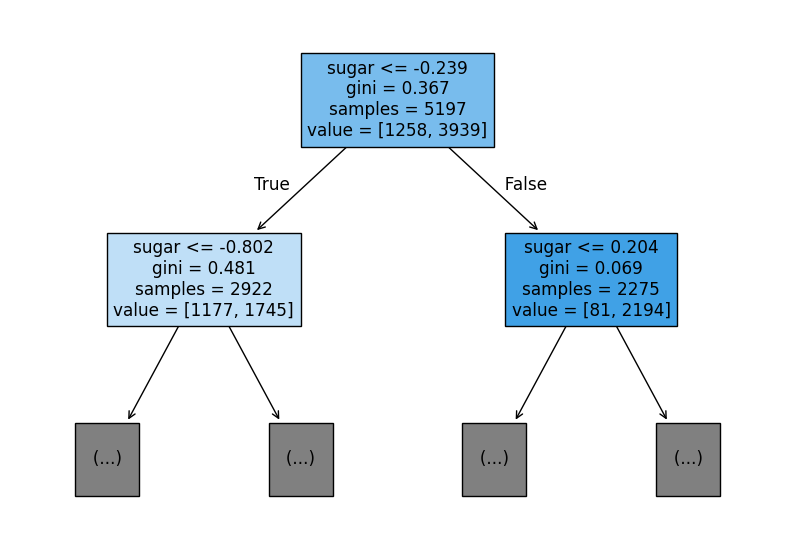

In [24]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 7)) 
# plot_tree(dt)

# 트리의 깊이를 제한해서 살펴보자
plot_tree(dt, max_depth=1, filled=True,
         feature_names=["alcohol", "sugar", "pH"])

plt.show()

위의 그림이 담고 있는 정보는 다음과 같다 :
  - 테스틑 조건(sugar)
  - 불순도(gini)
  - 총 샘플 수(samples)
  - 클래스별 샘플 수(value)

&rArr; 결정 트리에서는 리프 노드에서 가장 많은 클래스가 예측 클래스가 되는 방식으로 예측을 진행한다.

---

#### 불순도
gini는 **지니 불순도(Gini impurity)** 를 의미한다.\
`DecisionTreeClassifier` 클래스의 `criterion` 매개변수의 기본값이 "gini"이다.

<br>

지니 불순도는 **노드 안에 클래스가 얼마나 섞여 있는지를** 나타내는 지표이다.\
다음과 같이 계산된다 :
  - 1 - (음성 클래스 비율 ^ 2 + 양성 클래스 비율 ^2)
      - 0에 가까울수록 &rArr; 순수함(한 클래스만 섞여 있음) 
      - 값이 클수록 &rArr; 섞여 있음(여러 클래스 혼합)

<br>

그래서 이게 무슨 역할을 하는데?\
&rArr; 결정 트리는 분할할 때, **지니 불순도가 가장 많이 줄어드는 기준**을 선택한다.
<br>

불순도의 차이를 구해볼까?\
&rArr; `부모의 불순도 - (왼쪽 노드 샘플 수 / 부모의 샘플 수 ) x 왼쪽 노드 불순도 - (오른쪽 노드 샘플 수 / 부모의 샘플 수) x 오른쪽 노드 불순도`

&rArr; 어리한 불순도의 차이를 **정보 이득(information gain)** 이라고 한다.\
&rArr; 즉, 해당 알고리즘은 이 "정보 이득"이 최대가 되는 방향으로 데이터를 나누는 것이다.\

<br>

해당 클래스에서 `criterion=entropy`를 지정하여 "엔트로픠 불순도를 사용할 수 있다.\
해당 불순도도 클래스 비율을 사용하지만, 지니 처럼 제곱이 아니라, 밑이 2인 로그를 사용한다.
<br>
&rArr; 두 결과의 차이는 크지 않다.

---

#### 가지치기

가지치기를 잘 하지 않으면 훈련 세트에는 아주 잘 맞을 수는 있어도,
테스트 세트에서 점수는 그에 못 미칠 수 있다. = "일반화가 잘 안될 것 같다"

<br>

결정 트리에서 가지치기를 하는 가장 간단한 방법이 바로 "트리의 최대 깊이를 지정하는 것"이다.
  - `max_depth` 매개변수를 통해 가능하다.



0.8454877814123533
0.8415384615384616


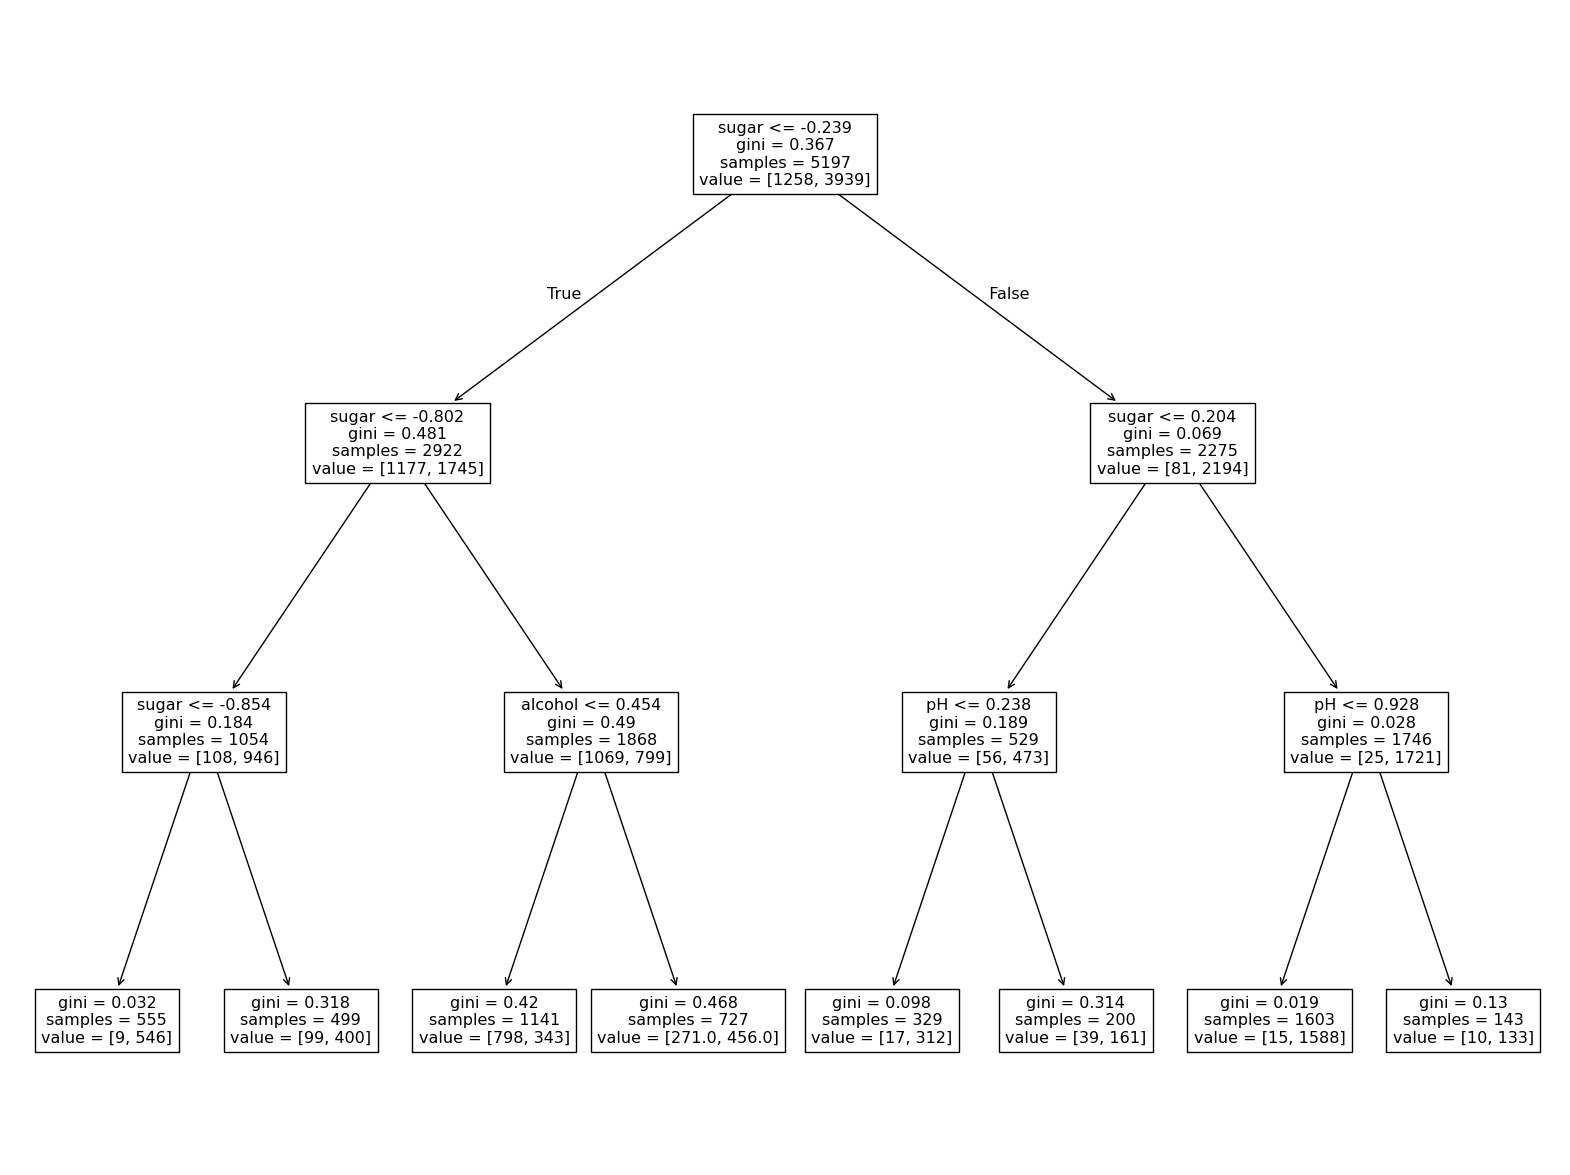

In [26]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)

dt.fit(train_scaled, train_target)

print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

plt.figure(figsize=(20, 15))
plot_tree(dt,feature_names=["alcohol", "sugar", 'pH'])
plt.show()

깊이 3의 왼쪽에서 세 번재에 있는 노드만이 음성 클래스가 더 많다.\
즉, 해당 노드에 도착해야만 레드 와인으로 에측한다는 것이다.
<br>

그렇다는 건 다음과 같다 :
  - 당도는 -0.239보다 작고 -0.802보다는 커야 한다.
  - 알코올 도수는 0.454보다 작아야 한다.
  - 당도는 -0.802보다 크고 -0.239보다 작은 것 중에,
  - 알코올 도수가 0.4545와 같거나 작은 것이 레드와인인 것이다.

근데 -0.802라는 음수로 정의된 당도를 어떻게 설명해야 할까..?

<br>

앞서 불순도는 클래스별 비율을 가지고 계산한다고 했다.\
그럼 샘플을 어떤 클래스 비율로 나누는지 계산할 때, 특성값의 스케일이 영향을 줄까?
<br>

&rArr; Nope, 따라서 결정 트리 알고리즘은 표준화 전처리를 할 필요가 없다.

0.8454877814123533
0.8415384615384616


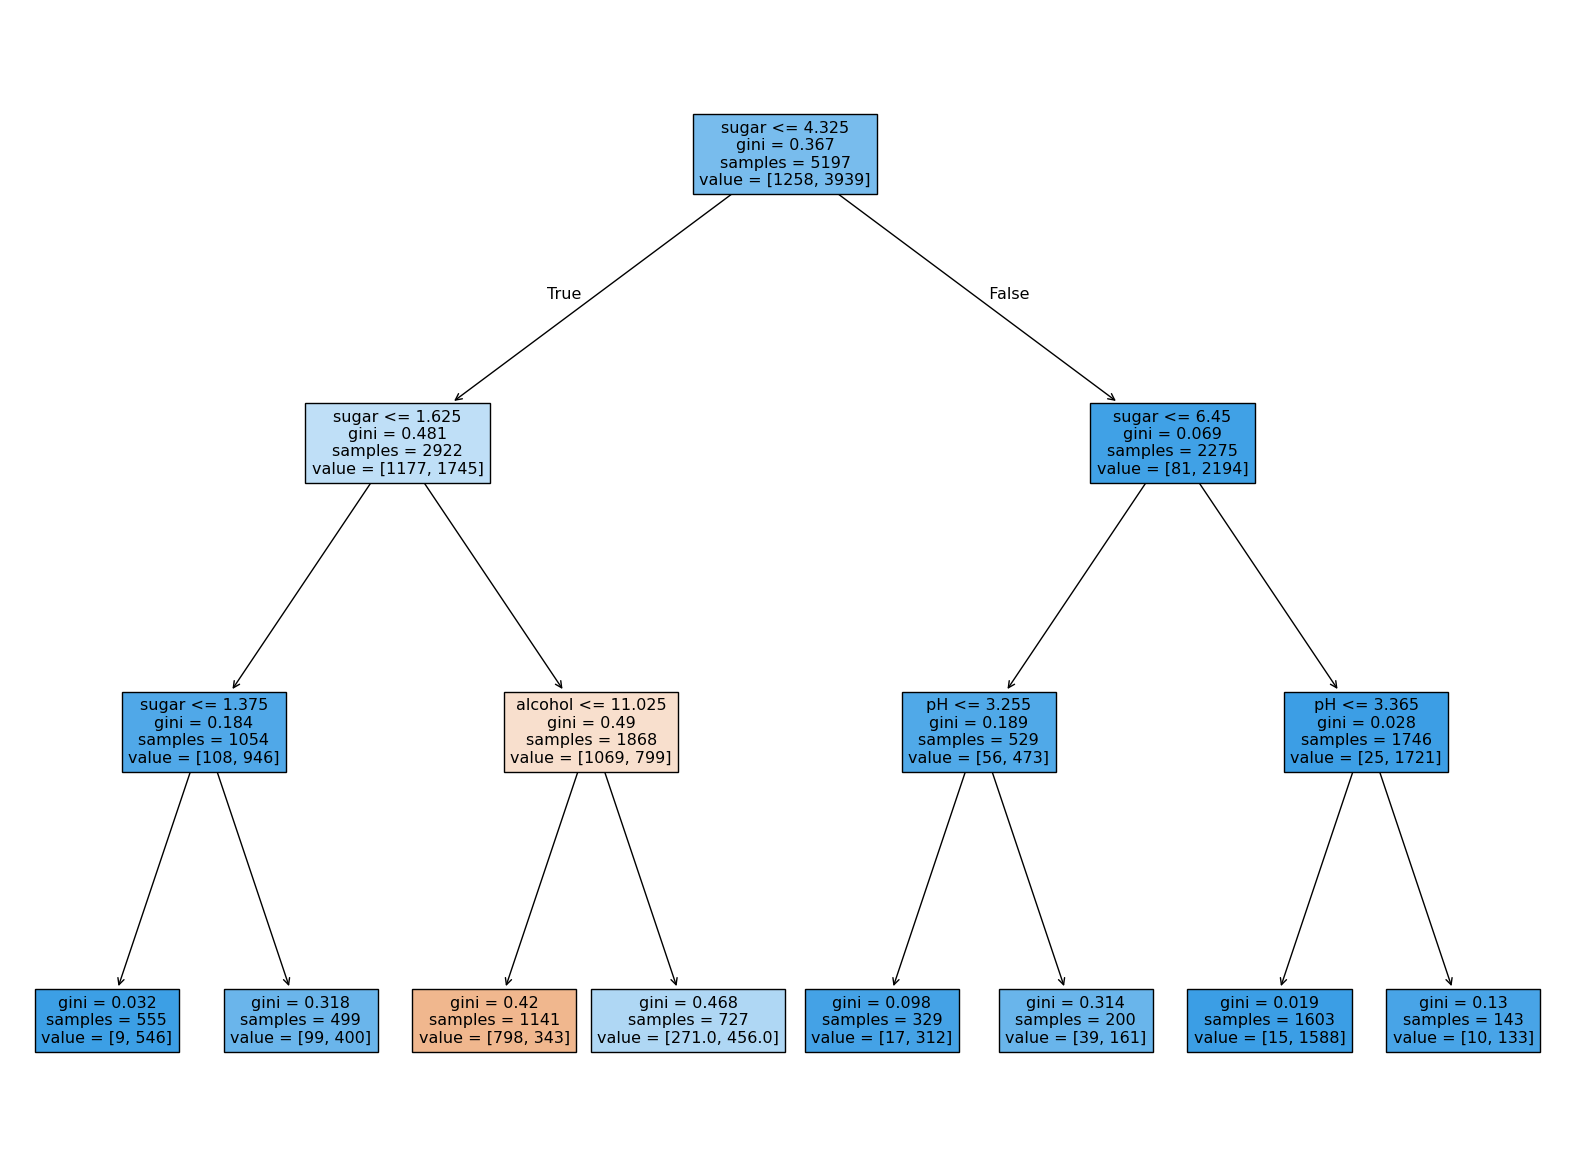

[0.12345626 0.86862934 0.0079144 ]


In [ ]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_input, train_target)

# 전처리 하기 전의 데이터를 활용해도 점수는 동일하다.
print(dt.score(train_input, train_target))
print(dt.score(test_input, test_target))

plt.figure(figsize=(20, 15))
plot_tree(dt, filled=True, feature_names=["alcohol", "sugar", "pH"])
plt.show()

결과를 보면 특성값을 표준점수로 바꾸지 않았기 때문에 이해하는 데에 훨씬 용이하다.
  - 당도가 1.625보다 크고 4.325보다 작은 와인 중
  - 알코올 도수가 11.025와 같거나 작은 것이 레드 와인이다.

<br>
마지막으로 결정 트리는 어떤 특성이 가장 유용한지 나타내는 특성 중요도를 계산해준다.

In [30]:
print(dt.feature_importances_)

[0.12345626 0.86862934 0.0079144 ]


---

앞서 우리는 와인의 분류를 위해서 "로지스틱 회귀" 모델을 적용했다.\
그 결과, 모든 점수가 낮게 나오며 과소적합이 발견되었다.

<br>

이를 해결 하기 위해 모델을 복잡하게 만들었다 :
  - `PolynomialFeature` 변환기 적용하여 다항 feature 추가
  - C(파라미터 규제)를 통해 모델의 복잡도를 제어
    > C는 규제의 역수이며,  
    > - C ↑ → 규제 약함 → 모델 복잡  
    > - C ↓ → 규제 강함 → 모델 단순  

&rArr; 이를 통해서 점수를 많이 끌어 올렸다.

---
 
##### 근데 결정 트리 점수랑 큰 차이 안나는데? 결정트리 사용한 것과 뭐가 다른거지?

성능 차이가 크지 않았던 이유는 다음과 같다 :
- Logistic Regression + Polynimial &rArr; **비선형을 억지로 표현**
- Decision Tree &rArr; **처음부터 비선형 모델**

즉, 두 모델 모두 **비슷한 수준의 표현력을 갖게 된 상테**이기 때문에 성능 차이가 나지 않았던 것이다.

---

결정 트리의 장점은 다음과 같다 :
  1. 전처리가 거의 필요 없다는 것이다.
      - 스케일링 X, 정규화 X, 다항 feature X 
      &rArr; 그냥 넣으면 된다.
  
  2. 비선형 관계를 자동으로 잡는다.
      - 앞서 로지스틱 회귀에서는 직선을 `poly`를 이용해서 억지로 곡선으로 만들었다.
      - 그러나 결정 트리는 처음부터 비선형이다.

  3. 해석이 직관적이다.
      - 트리는 다음과 같이 읽을 수 있다 :
          ```text
          if sugar < 5:
          if alcohol > 10:
            class = A
          ```
      
      - 로지스틱 회귀는 계수 보고 해석을 해야 한다. (직관성이 떨어진다.)

  4. feqture 간 상호작용 자동 처리
      - 로지스틱 회귀는 `poly`를 통해서 사람이 직접 만들어 줬어야 했다.
      - 하지만 결정 트리는 자동으로 조합한다.

  5. 이상치(outlier)에 강하다
      - 로지스틱은 영향을 받는다. (그래서 스케일링 했었다.)
      - 트리는 거의 영향 받지 않는다. (왜냐하면 값 크기 자체가 중요하지 않기 때문이다.)

  
##### 결정 트리가 다 좋지는 않을거 아니야...

결정 트리의 단점은 다음과 같다 :
  1. 과적합이 잘 된다 : 깊어지면 데이터를 외워버린다.
  2. 일반화 성능이 약하다 : 테스트에서 개질 수 있다.
  3. 불안정하다 : 데이터가 조금 바뀌면 구조가 확 바뀌게 된다.

&rArr; 따라서 Decision Tree 단독으로 쓰기 보다는, 트리를 "여러 개 묶어서" 사용한다.

--- 

#### 결론

- Logistic Regression &rArr; 수학적으로 안정적이고 일반화가 좋은 모델
- Decision Tree &rArr; 직관적이지만 과적합 위험이 존재
